# dsQTL

(17506, 1000) (17506, 1000) (17506, 1) (17506, 1)


/tmp/ipykernel_1252102/4003902943.py:98: RuntimeWarning: invalid value encountered in log
  log_probs_diff_abs_sum =  np.sum(np.abs(np.log(alt_prob_preds) -  np.log(ref_prob_preds)),axis=1)


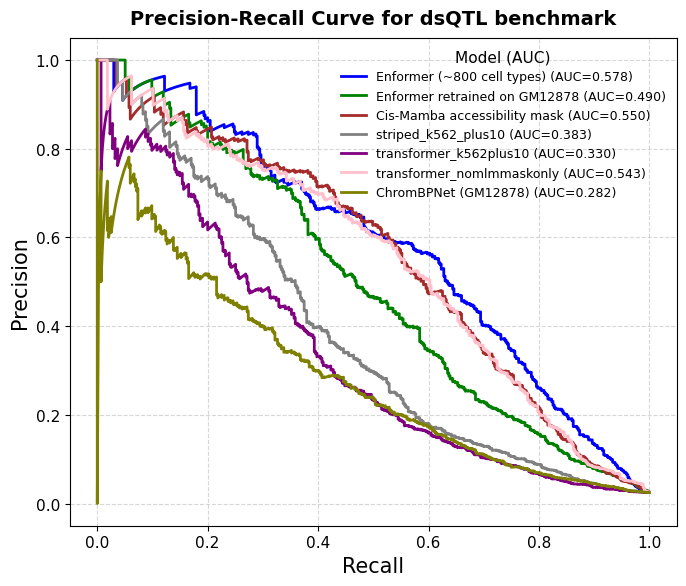

In [1]:
#let's load this in and compare

from sklearn.metrics import roc_curve, precision_recall_curve, auc
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt
import zarr


def predict_snp_effect_scores(ref_prob_preds, alt_prob_preds):
    '''
    Predicts variant effect scores based on model predictions.

    Arguments::
       ref_logcount_preds: log count predictions at the reference allele with size (N,)
       alt_logcount_preds: log count predictions at the alternate alele with size (N,)
       ref_prob_preds: profile probability predictions at the reference allele with size (N,outputlen). outputlen depends on the model.
       alt_prob_preds:  profile probability predictions at the alternate allele with size (N,outputlen). outputlen depends on the model.
    
    Returns:
        log_counts_diff: difference in log count predictions of alternate and reference allele (N,)
        log_probs_diff_abs_sum: Sum of absolute difference in log probability prediction of alternate and reference allele per base. (N,)
        probs_jsd_diff: Jensenshannon distance between probability predictions of alternate and reference allele (N,)
    '''
    # log_counts_diff = np.mean(alt_prob_preds, axis=1) - np.mean(ref_prob_preds, axis=1) #model doesn't have count prediction head, so it's really bad!
    # log_counts_diff = alt_count_preds - ref_count_preds
    log_probs_diff_abs_sum =  np.sum(np.abs(np.log(alt_prob_preds) -  np.log(ref_prob_preds)),axis=1)
    probs_jsd_diff = np.array([jensenshannon(x,y) for x,y in zip(alt_prob_preds, ref_prob_preds)])
    # integrative_effect_size = log_probs_diff_abs_sum * probs_jsd_diff
    logfc = np.log2(ref_prob_preds.mean(1) / alt_prob_preds.mean(1))
    integrative_effect_size = logfc * probs_jsd_diff
    integrative_effect_size_2 = log_probs_diff_abs_sum * probs_jsd_diff

    return logfc, log_probs_diff_abs_sum, probs_jsd_diff, integrative_effect_size, integrative_effect_size_2



qtls = pd.read_csv('/data1/lesliec/sarthak/data/joint_playground/dsQTL/filtered_dsqtls.txt', sep='\t')
def plot_metrics(out, labels, title):
    model_names = ['logfc', 'log_probs_diff_abs_sum', 'JSD', 'IED1', 'IED2']
    colors = ['blue', 'green', 'red', 'orange', 'purple']

    plt.figure(figsize=(6, 5))

    # # === ROC Curve ===
    # plt.subplot(1, 2, 1)
    # for i in range(len(model_names)):
    #     fpr, tpr, _ = roc_curve(labels, out[i])
    #     roc_auc = auc(fpr, tpr)
    #     plt.plot(fpr, tpr, label=f'{model_names[i]} (AUC = {roc_auc:.3f})', color=colors[i])

    # plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    # plt.title('ROC Curve')
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')
    # plt.legend()

    # === Precision-Recall Curve ===
    # plt.subplot(1, 2, 2)
    for i in range(len(model_names)):
        precision, recall, _ = precision_recall_curve(labels, np.abs(out[i]))
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'{model_names[i]} (AUC = {pr_auc:.3f})', color=colors[i])

    plt.title(title)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()

    plt.tight_layout()
    # plt.suptitle(title)
    plt.show()
    
def softmax(x, temp=1):
    norm_x = x - np.mean(x, axis=1, keepdims=True)
    return np.exp(temp*norm_x)/np.sum(np.exp(temp*norm_x), axis=1, keepdims=True)

def predict_snp_effect_scores_bpnet(ref_prob_preds, alt_prob_preds, ref_count_preds, alt_count_preds):
    '''
    Predicts variant effect scores based on model predictions.

    Arguments::
       ref_logcount_preds: log count predictions at the reference allele with size (N,)
       alt_logcount_preds: log count predictions at the alternate alele with size (N,)
       ref_prob_preds: profile probability predictions at the reference allele with size (N,outputlen). outputlen depends on the model.
       alt_prob_preds:  profile probability predictions at the alternate allele with size (N,outputlen). outputlen depends on the model.
    
    Returns:
        log_counts_diff: difference in log count predictions of alternate and reference allele (N,)
        log_probs_diff_abs_sum: Sum of absolute difference in log probability prediction of alternate and reference allele per base. (N,)
        probs_jsd_diff: Jensenshannon distance between probability predictions of alternate and reference allele (N,)
    '''
    
    print(ref_prob_preds.shape, alt_prob_preds.shape, ref_count_preds.shape, alt_count_preds.shape)
    # log_counts_diff = np.mean(alt_prob_preds, axis=1) - np.mean(ref_prob_preds, axis=1) #model doesn't have count prediction head, so it's really bad!
    # log_counts_diff = alt_count_preds - ref_count_preds
    log_probs_diff_abs_sum =  np.sum(np.abs(np.log(alt_prob_preds) -  np.log(ref_prob_preds)),axis=1)
    #and account for nan
    log_probs_diff_abs_sum[np.isnan(log_probs_diff_abs_sum)] = 0
    # probs_jsd_diff = np.array([jensenshannon(softmax(x),softmax(y)) for x,y in zip(alt_prob_preds, ref_prob_preds)])
    probs_jsd_diff = np.squeeze([jensenshannon(x, y, base=2.0)
                     for x,y in zip(softmax(alt_prob_preds),
                                    softmax(ref_prob_preds))])
    # integrative_effect_size = log_probs_diff_abs_sum * probs_jsd_diff
    logfc = np.log2(ref_count_preds/alt_count_preds)[:,0]
    integrative_effect_size = logfc * probs_jsd_diff
    integrative_effect_size_2 = log_probs_diff_abs_sum * probs_jsd_diff

    return logfc, log_probs_diff_abs_sum, probs_jsd_diff, integrative_effect_size, integrative_effect_size_2
    
labels = qtls['label'].to_numpy()

def plot_selected_metric(files, labels, metric_name='logfc', sort_legend_by_auc=False, enformer_center=False, titles=None, title=None):
    """
    Plots publication-ready Precision-Recall curves for selected SNP effect metrics.
    """
    metric_index_map = {
        'logfc': 0,
        'log_probs_diff_abs_sum': 1,
        'JSD': 2,
        'IED1': 3,
        'IED2': 4
    }
    assert metric_name in metric_index_map, f"Invalid metric: {metric_name}"
    metric_idx = metric_index_map[metric_name]

    # Set up the figure
    plt.figure(figsize=(7, 6))
    plt.rcParams.update({'font.size': 11})

    # Color cycle and line style
    # color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    line_width = 2

    colors = ['blue', 'green', 'brown', 'gray', 'purple', 'pink', 'olive', 'cyan']

    legend_entries = []

    # Plot each model's PR curve
    for i, file in enumerate(files):
        if file.endswith('.npz'):
            pred_cbp = np.load('/data1/lesliec/sarthak/data/joint_playground/chrombpnet/GM12878_Tcellbias/var_prds.npz')
            out = predict_snp_effect_scores_bpnet(
                pred_cbp['profile'][:, :, 0],
                pred_cbp['profile'][:, :, 1],
                pred_cbp['counts'][:, :, 0],
                pred_cbp['counts'][:, :, 1]
            )
        elif file.endswith('zarr'):
            eqtl_data = zarr.open(f'/data1/lesliec/sarthak/data/joint_playground/dsQTL/{file}')
            out = predict_snp_effect_scores(eqtl_data[:, :, 0], eqtl_data[:, :, 1])
        else:
            eqtl_data = np.load(f'/data1/lesliec/sarthak/data/joint_playground/dsQTL/{file}')
            if enformer_center and 'enformer' in file:
                eqtl_data = eqtl_data[:, 440:456, :]
            out = predict_snp_effect_scores(eqtl_data[:, :, 0], eqtl_data[:, :, 1])

        if i == 0:
            non_zero_mask = (out[0] != 0)

        scores = np.abs(out[metric_idx])[non_zero_mask]
        precision, recall, _ = precision_recall_curve(labels[non_zero_mask], scores)
        pr_auc = auc(recall, precision)

        line, = plt.plot(
            recall,
            precision,
            label=titles[i] if titles else file,
            color=colors[i],
            linewidth=line_width
        )
        legend_entries.append((pr_auc, line, f"{titles[i]} (AUC={pr_auc:.3f})"))

    # Format title and labels
    plt.title(
        title or f'Precision–Recall Curve ({metric_name.upper()})',
        fontsize=14,
        fontweight='bold',
        pad=10
    )
    plt.xlabel('Recall', fontsize=15)
    plt.ylabel('Precision', fontsize=15)

    # Grid for readability
    plt.grid(axis='both', linestyle='--', alpha=0.5)

    # Sort legend by AUC if requested
    if sort_legend_by_auc:
        legend_entries.sort(key=lambda x: x[0], reverse=True)
    handles = [entry[1] for entry in legend_entries]
    labels_sorted = [entry[2] for entry in legend_entries]

    # Legend styling
    plt.legend(
        handles,
        labels_sorted,
        title='Model (AUC)',
        title_fontsize=11,
        fontsize=9,
        loc='upper right',
        frameon=False
    )

    # Tight layout and display
    plt.tight_layout()
    plt.show()

files = ['enformer_dsqtl.npy', 'enformer_dsqtl_retrained-dsqtl.npy', 'nomlm_maskonly.npy', 'striped_16000steps.npy', 'transformer_k562plus10.npy', 'transformer_nomlmmaskonly.npy', '.npz']
titles = ['Enformer (~800 cell types)', 'Enformer retrained on GM12878', 'Cis-Mamba accessibility mask', 'striped_k562_plus10', 'transformer_k562plus10', 'transformer_nomlmmaskonly',
                     'ChromBPNet (GM12878)']
plot_selected_metric(files, labels, metric_name='logfc', sort_legend_by_auc=False, enformer_center=True, titles=titles, title='Precision-Recall Curve for dsQTL benchmark')

In [14]:
def plot_auc_bar(
    files, labels, metric_name='logfc', colors=None, titles=None,
    title=None, sort_descending=True, enformer_center=False,
    figsize=(10, 5), bar_width=0.55
):
    metric_index_map = {
        'logfc': 0, 'log_probs_diff_abs_sum': 1,
        'JSD': 2, 'IED1': 3, 'IED2': 4
    }
    assert metric_name in metric_index_map, f"Invalid metric: {metric_name}"
    metric_idx = metric_index_map[metric_name]

    default_colors = [
        '#4878CF', '#D65F5F', '#6ACC65', '#B47CC7',
        '#C4AD66', '#77BEDB', '#F28E2B', '#59A89C',
    ]
    if colors is None:
        colors = default_colors

    full_entries = []  # (auc, label, color) for every entry in order
    first_real_file_seen = False

    for i, file in enumerate(files):
        label = titles[i] if titles else (str(file) if isinstance(file, (int, float)) else file)
        color = colors[i % len(colors)]

        # ── Pre-computed scalar: no file loading needed ────────────────────
        if isinstance(file, (int, float)):
            full_entries.append((file, label, color))
            continue

        # ── File loading — verbatim from plot_selected_metric ──────────────
        if file.endswith('.npz'):
            pred_cbp = np.load('/data1/lesliec/sarthak/data/joint_playground/chrombpnet/GM12878_Tcellbias/var_prds.npz')
            out = predict_snp_effect_scores_bpnet(
                pred_cbp['profile'][:, :, 0],
                pred_cbp['profile'][:, :, 1],
                pred_cbp['counts'][:, :, 0],
                pred_cbp['counts'][:, :, 1]
            )
        elif file.endswith('zarr'):
            eqtl_data = zarr.open(f'/data1/lesliec/sarthak/data/joint_playground/dsQTL/{file}')
            out = predict_snp_effect_scores(eqtl_data[:, :, 0], eqtl_data[:, :, 1])
        else:
            eqtl_data = np.load(f'/data1/lesliec/sarthak/data/joint_playground/dsQTL/{file}')
            if enformer_center and 'enformer' in file:
                eqtl_data = eqtl_data[:, 440:456, :]
            out = predict_snp_effect_scores(eqtl_data[:, :, 0], eqtl_data[:, :, 1])

        # ── Mask set from first real file only — verbatim ──────────────────
        if not first_real_file_seen:
            non_zero_mask = (out[0] != 0)
            first_real_file_seen = True

        scores = np.abs(out[metric_idx])[non_zero_mask]
        precision, recall, _ = precision_recall_curve(labels[non_zero_mask], scores)
        pr_auc = auc(recall, precision)
        full_entries.append((pr_auc, label, color))

    if sort_descending:
        full_entries.sort(key=lambda x: x[0], reverse=True)

    auc_scores, bar_labels, bar_colors = zip(*full_entries)

    # ── Plot ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    x = np.arange(len(bar_labels))
    bars = ax.bar(x, auc_scores, width=bar_width,
                  color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3)

    ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='#DDDDDD', zorder=0)
    ax.set_axisbelow(True)

    y_max = max(auc_scores)
    y_min = max(0, min(auc_scores) * 0.92)
    for bar, val in zip(bars, auc_scores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_max * 0.015,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=10.5, fontweight='bold', color='#222222'
        )

    ax.set_ylim(y_min, y_max * 1.13)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
    ax.set_ylabel('PR-AUC', fontsize=12, color='#444444', labelpad=10)
    ax.tick_params(axis='y', labelsize=10, colors='#555555', length=0)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=35, ha='right', fontsize=10.5, color='#222222')
    ax.tick_params(axis='x', length=0)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['bottom'].set_linewidth(0.8)
    ax.axhline(y_min, color='#CCCCCC', linewidth=0.8)

    ax.set_title(
        title or f'PR-AUC Comparison ({metric_name})',
        fontsize=13, fontweight='bold', color='#111111', pad=16, loc='left'
    )

    plt.tight_layout()
    plt.show()

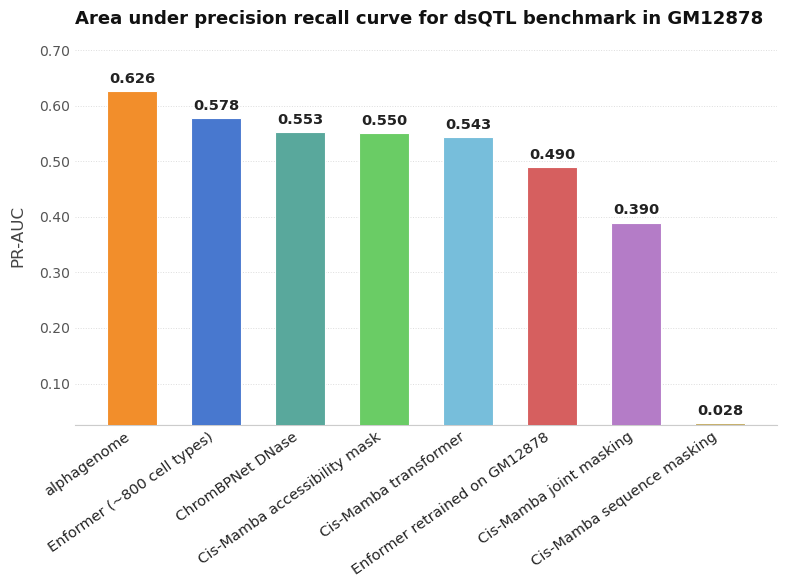

In [18]:
colors = [
    '#4878CF',  # steel blue
    '#D65F5F',  # muted red
    '#6ACC65',  # soft green
    '#B47CC7',  # lavender purple
    '#C4AD66',  # warm tan/gold
    '#77BEDB',  # sky blue
    '#F28E2B',  # amber orange
    '#59A89C',  # teal
]
files = ['enformer_dsqtl.npy', 'enformer_dsqtl_retrained-dsqtl.npy', 'nomlm_maskonly.npy', 'base_dsqtl_mask_1000.npy', 'gm12878_noacc_.npy', 'transformer_nomlmmaskonly.npy', 'alphagenome_dsqtl.zarr', 0.553]
titles = ['Enformer (~800 cell types)', 'Enformer retrained on GM12878', 'Cis-Mamba accessibility mask', 'Cis-Mamba joint masking', 'Cis-Mamba sequence masking', 'Cis-Mamba transformer', 'alphagenome',
                     'ChromBPNet DNase', 'ChromBPNet ATAC']
plot_auc_bar(
    files=files,
    labels=labels,
    metric_name='logfc',
    colors=colors,
    titles=titles,
    title='Area under precision recall curve for dsQTL benchmark in GM12878',
    sort_descending=True,
    figsize=(8, 6),
    enformer_center=True,
    bar_width=0.6,
)

In [ ]:
def compute_auc_scores(files, labels, metric_name='logfc', enformer_center=False, titles=None):
    metric_index_map = {
        'logfc': 0, 'log_probs_diff_abs_sum': 1,
        'JSD': 2, 'IED1': 3, 'IED2': 4
    }
    assert metric_name in metric_index_map, f"Invalid metric: {metric_name}"
    metric_idx = metric_index_map[metric_name]

    results = []
    first_real_file_seen = False

    for i, file in enumerate(files):
        label = titles[i] if titles else str(file)

        if isinstance(file, (int, float)):
            results.append((file, label))
            continue

        if file.endswith('.npz'):
            pred_cbp = np.load('/data1/lesliec/sarthak/data/joint_playground/chrombpnet/GM12878_Tcellbias/var_prds.npz')
            out = predict_snp_effect_scores_bpnet(
                pred_cbp['profile'][:, :, 0],
                pred_cbp['profile'][:, :, 1],
                pred_cbp['counts'][:, :, 0],
                pred_cbp['counts'][:, :, 1]
            )
        elif file.endswith('zarr'):
            eqtl_data = zarr.open(f'/data1/lesliec/sarthak/data/joint_playground/dsQTL/{file}')
            out = predict_snp_effect_scores(eqtl_data[:, :, 0], eqtl_data[:, :, 1])
        else:
            eqtl_data = np.load(f'/data1/lesliec/sarthak/data/joint_playground/dsQTL/{file}')
            if enformer_center and 'enformer' in file:
                eqtl_data = eqtl_data[:, 440:456, :]
            out = predict_snp_effect_scores(eqtl_data[:, :, 0], eqtl_data[:, :, 1])

        if not first_real_file_seen:
            non_zero_mask = (out[0] != 0)
            first_real_file_seen = True

        scores = np.abs(out[metric_idx])[non_zero_mask]
        precision, recall, _ = precision_recall_curve(labels[non_zero_mask], scores)
        pr_auc = auc(recall, precision)
        results.append((pr_auc, label))

    return results  # list of (auc_score, label)


def plot_auc_bar(
    results, colors=None, title=None,
    sort_descending=True, figsize=(10, 5), bar_width=0.55
):
    """
    Arguments:
        results: list of (auc_score, label) as returned by compute_auc_scores
        colors:  list of colors, one per entry
    """
    default_colors = [
        '#4878CF', '#D65F5F', '#6ACC65', '#B47CC7',
        '#C4AD66', '#77BEDB', '#F28E2B', '#59A89C',
    ]
    if colors is None:
        colors = default_colors

    full_entries = [(auc, label, colors[i % len(colors)]) for i, (auc, label) in enumerate(results)]

    if sort_descending:
        full_entries.sort(key=lambda x: x[0], reverse=True)

    auc_scores, bar_labels, bar_colors = zip(*full_entries)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    x = np.arange(len(bar_labels))
    bars = ax.bar(x, auc_scores, width=bar_width,
                  color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3)

    ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='#DDDDDD', zorder=0)
    ax.set_axisbelow(True)

    y_max = max(auc_scores)
    y_min = max(0, min(auc_scores) * 0.92)
    for bar, val in zip(bars, auc_scores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_max * 0.015,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=10.5, fontweight='bold', color='#222222'
        )

    ax.set_ylim(y_min, y_max * 1.13)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
    ax.set_ylabel('PR-AUC', fontsize=12, color='#444444', labelpad=10)
    ax.tick_params(axis='y', labelsize=10, colors='#555555', length=0)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=35, ha='right', fontsize=10.5, color='#222222')
    ax.tick_params(axis='x', length=0)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['bottom'].set_linewidth(0.8)
    ax.axhline(y_min, color='#CCCCCC', linewidth=0.8)

    ax.set_title(
        title or 'PR-AUC Comparison',
        fontsize=13, fontweight='bold', color='#111111', pad=16, loc='left'
    )

    plt.tight_layout()
    plt.show()

files = ['enformer_dsqtl.npy', 'enformer_dsqtl_retrained-dsqtl.npy', 'nomlm_maskonly.npy', 'base_dsqtl_mask_1000.npy', 'gm12878_noacc_.npy', 'transformer_nomlmmaskonly.npy', 'alphagenome_dsqtl.zarr', 0.553]
titles = ['Enformer (~800 cell types)', 'Enformer retrained on GM12878', 'Cis-Mamba accessibility mask', 'Cis-Mamba joint masking', 'Cis-Mamba sequence masking', 'Cis-Mamba transformer', 'alphagenome',
                     'ChromBPNet DNase', 'ChromBPNet ATAC']
results = compute_auc_scores(files, labels, metric_name='logfc', enformer_center=True, titles=titles)

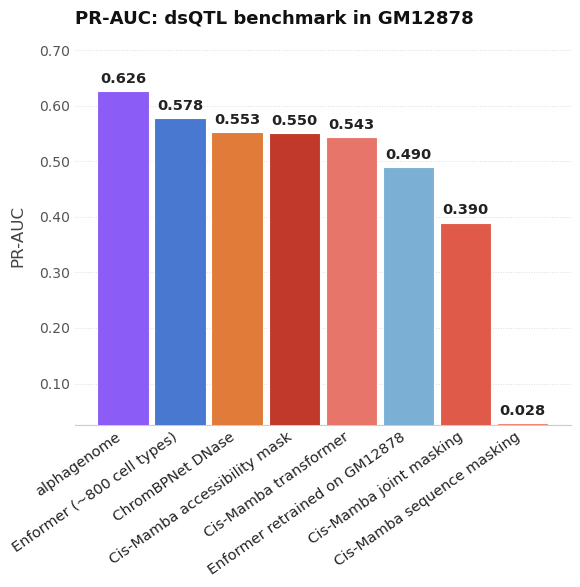

In [38]:
colors = [
    '#4878CF',  # Enformer (~800 cell types)        — blue
    '#7BAFD4',  # Enformer retrained on GM12878      — light blue

    '#C0392B',  # Cis-Mamba accessibility mask       — dark red
    '#E05A4A',  # Cis-Mamba joint masking            — medium red
    '#F08070',  # Cis-Mamba sequence masking         — light red
    '#E8756A',  # Cis-Mamba transformer              — salmon red

    '#8B5CF6',  # AlphaGenome                        — purple

    '#E07B39',  # ChromBPNet DNase                   — dark orange
    '#F4A95A',  # ChromBPNet ATAC                    — light orange
]
files = ['enformer_dsqtl.npy', 'enformer_dsqtl_retrained-dsqtl.npy', 'nomlm_maskonly.npy', 'base_dsqtl_mask_1000.npy', 'gm12878_noacc_.npy', 'transformer_nomlmmaskonly.npy', 'alphagenome_dsqtl.zarr', 0.553]
titles = ['Enformer (~800 cell types)', 'Enformer retrained on GM12878', 'Cis-Mamba accessibility mask', 'Cis-Mamba joint masking', 'Cis-Mamba sequence masking', 'Cis-Mamba transformer', 'alphagenome',
                     'ChromBPNet DNase', 'ChromBPNet ATAC']
plot_auc_bar(results,
    colors=colors,
    title='PR-AUC: dsQTL benchmark in GM12878',
    sort_descending=True,
    figsize=(6, 6),
    bar_width=0.9,
)

# expression prediction

(1937, 896)
(1937, 896)
(1937, 896)
(1937, 896)
True
True
Processing enformer with shape (1937, 896)


100%|██████████| 1937/1937 [00:01<00:00, 985.86it/s] 


Processing GM12878_no_mlm_predictions.npy with shape (1937, 896)


100%|██████████| 1937/1937 [00:01<00:00, 1043.41it/s]


Processing immune_CAGE_predictions.npy with shape (1937, 896)


100%|██████████| 1937/1937 [00:01<00:00, 1038.66it/s]


Processing nopretrain_predictions.npy with shape (1937, 896)


100%|██████████| 1937/1937 [00:01<00:00, 1014.40it/s]


ValueError: Dimensions of labels and X must be compatible

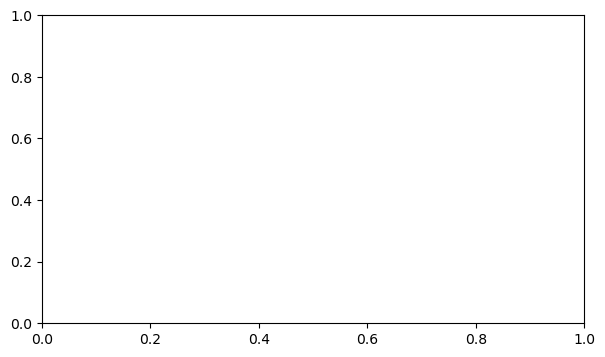

In [1]:
#That's a, now let's do b and c

import numpy as np
enformer_full = np.load('/data1/lesliec/sarthak/data/enformer/data/model_out/enformer.npy')
enformer_full.shape
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
# import torch

model_names = ['enformer', 'GM12878_no_mlm_predictions.npy', 'immune_CAGE_predictions.npy', 'nopretrain_predictions.npy']
# enformer = np.load('/data1/lesliec/sarthak/data/enformer/data/model_out/enformer.npy')

preds = {}
for model_name in model_names:
    if model_name == 'enformer':
        preds[model_name] = enformer_full[:, :, 5110]
    else:
        preds[model_name] = np.load(f'/data1/lesliec/sarthak/data/joint_playground/model_out/{model_name}')
        if preds[model_name].ndim == 3:
            preds[model_name] = preds[model_name][:,:,0]
    print(preds[model_name].shape)
#now let's make sure the targets are the same
t1 = np.load('/data1/lesliec/sarthak/data/joint_playground/model_out/GM12878_base_targets_conv.npy')
t2 = np.load('/data1/lesliec/sarthak/data/joint_playground/model_out/nobcell_CAGE_targets.npy')[:,:,0]
t3 = np.load('/data1/lesliec/sarthak/data/joint_playground/model_out/immune_CAGE_targets.npy')[:,:,0]
t1.shape, t2.shape, t3.shape
#and now see how similar
print(np.allclose(t1, t2))
print(np.allclose(t1, t3)) #perfect!
#now let's just correlate
from scipy.stats import spearmanr, pearsonr
spearman_results = {}
pearson_results  = {}

for name, arr in preds.items():
    # sanity check: shapes match
    print(f"Processing {name} with shape {arr.shape}")
    assert arr.shape == t1.shape, f"{name} vs t1 shape mismatch!"
    # loop over samples
    sp = []
    pp = []
    for i in tqdm(range(arr.shape[0])):
        s = spearmanr(arr[i], t1[i])[0]
        p = pearsonr(arr[i], t1[i])[0]
        sp.append(s)
        pp.append(p)
    spearman_results[name] = np.array(sp)
    pearson_results [name] = np.array(pp)


import matplotlib.pyplot as plt
import numpy as np

# Desired order of models (match keys in spearman_results)
ordered_keys = [
    'enformer',
    'GM12878_no_mlm_predictions.npy',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy',
]

# Pretty display labels
pretty_labels = [
    'Enformer',
    'Cis-Mamba \n(GM12878)',
    'Cis-Mamba \n(8 immune cell types)',
    'Cis-Mamba \n(No-pretrain)',
    'Cis-Mamba \n(8 immune cell types + CTT)'
]

# Matching colors (same order)
colors = ['#1f77b4',  # blue
          '#d62728',  # red
          '#2ca02c',  # green
          '#9467bd',  # purple
          '#ff7f0e']  # orange

# Pull data in correct order
data = [spearman_results[k] for k in ordered_keys]

# Plot
plt.figure(figsize=(7, 4))
box = plt.boxplot(data, labels=pretty_labels, showfliers=False, patch_artist=True,
                  boxprops=dict(edgecolor='black'),
                  medianprops=dict(color='black', linewidth=2),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'))

# Color each box
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Annotate mean values on each box
for i, vals in enumerate(data):
    mean_val = np.mean(vals)
    plt.text(i + 1, mean_val, f"{mean_val:.2f}",  # slight offset above median
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Labels and formatting
plt.ylabel("Spearman correlation", fontsize=12)
plt.title("GM12878 Test Set Expression Prediction, Spearman Correlation", fontsize=13, weight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


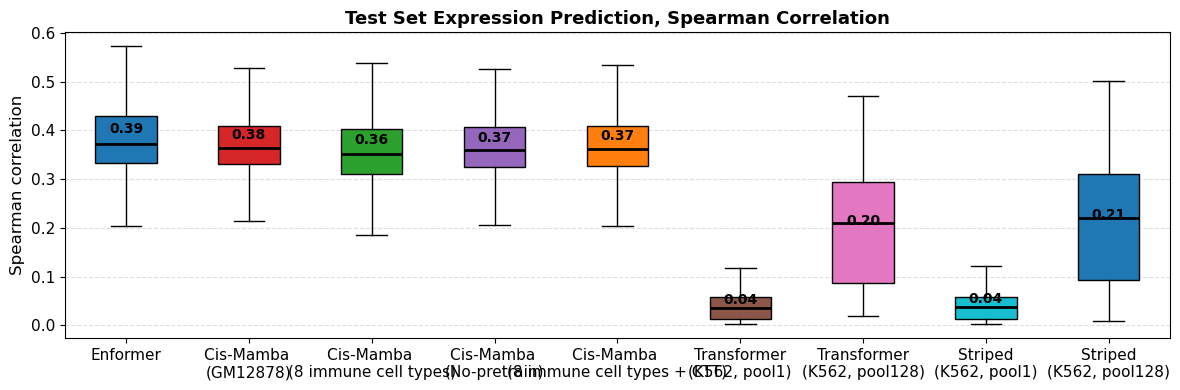

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load pre-computed correlation .npy files ---
# Shape: (samples, celltypes, 2) → average strands, pick celltype index 4
def load_corr(path):
    arr = np.load(path)          # (samples, celltypes, 2)
    return arr[:, 4, :].mean(axis=-1)  # (samples,)

new_corrs = {
    'transformer_k562_pool1':   load_corr('/data1/lesliec/sarthak/data/joint_playground/model_out/transformer_k562_pool1_spearman.npy'),
    'transformer_k562_pool128': load_corr('/data1/lesliec/sarthak/data/joint_playground/model_out/transformer_k562_pool128_spearman.npy'),
    'striped_k562_pool1':     load_corr('/data1/lesliec/sarthak/data/joint_playground/model_out/striped_k562_pool1_spearman.npy'),
    'striped_k562_pool128':     load_corr('/data1/lesliec/sarthak/data/joint_playground/model_out/striped_k562_pool128_spearman.npy'),
}

# --- Extend your existing ordered_keys / labels / colors ---
ordered_keys_all = ordered_keys + list(new_corrs.keys())

pretty_labels_all = pretty_labels + [
    'Transformer\n(K562, pool1)',
    'Transformer\n(K562, pool128)',
    'Striped\n(K562, pool1)',
    'Striped\n(K562, pool128)',
]

colors_all = colors + [
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#17becf',  # cyan
]

# --- Pull all data in order ---
data_all = [spearman_results[k] for k in ordered_keys] + [new_corrs[k] for k in new_corrs]

# --- Plot ---
plt.figure(figsize=(12, 4))
box = plt.boxplot(data_all, labels=pretty_labels_all, showfliers=False, patch_artist=True,
                  boxprops=dict(edgecolor='black'),
                  medianprops=dict(color='black', linewidth=2),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'))

for patch, color in zip(box['boxes'], colors_all):
    patch.set_facecolor(color)

for i, vals in enumerate(data_all):
    mean_val = np.mean(vals)
    plt.text(i + 1, mean_val, f"{mean_val:.2f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel("Spearman correlation", fontsize=12)
plt.title("Test Set Expression Prediction, Spearman Correlation", fontsize=13, weight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

100%|██████████| 1937/1937 [00:00<00:00, 2092.99it/s]


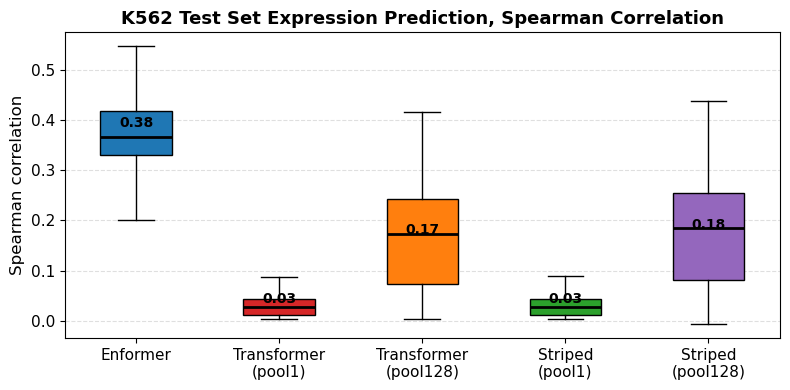

In [8]:
#now striped models both with and without pooling, but have to redo the plotting altogether lol
#let's also check k562 performance
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from tqdm import tqdm

# --- Enformer K562 ---
enformer_k562 = enformer_full[:, :, 5111]  # shape: (samples, bins)
sp = []
for i in tqdm(range(enformer_k562.shape[0])):
    s = spearmanr(enformer_k562[i], t1[i])[0]  # reuse t1 or swap for k562 target!
    sp.append(s)
spearman_k562_enformer = np.array(sp)

# --- Load pre-computed K562 spearman arrays (celltype index 1, average strands) ---
def load_corr(path, ct_idx=1):
    arr = np.load(path)               # (samples, celltypes, 2)
    return arr[:, ct_idx, :].mean(axis=-1)

k562_corrs = {
    'transformer_pool1':   load_corr('/data1/lesliec/sarthak/data/joint_playground/model_out/transformer_k562_pool1_spearman.npy'),
    'transformer_pool128': load_corr('/data1/lesliec/sarthak/data/joint_playground/model_out/transformer_k562_pool128_spearman.npy'),
    'striped_pool1':       load_corr('/data1/lesliec/sarthak/data/joint_playground/model_out/striped_k562_pool1_spearman.npy'),
    'striped_pool128':     load_corr('/data1/lesliec/sarthak/data/joint_playground/model_out/striped_k562_pool128_spearman.npy'),
}

# --- Assemble plot data ---
data = [
    spearman_k562_enformer,
    k562_corrs['transformer_pool1'],
    k562_corrs['transformer_pool128'],
    k562_corrs['striped_pool1'],
    k562_corrs['striped_pool128'],
]

pretty_labels = [
    'Enformer',
    'Transformer\n(pool1)',
    'Transformer\n(pool128)',
    'Striped\n(pool1)',
    'Striped\n(pool128)',
]

colors = [
    '#1f77b4',  # blue
    '#d62728',  # red
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#9467bd',  # purple
]

# --- Plot ---
plt.figure(figsize=(8, 4))
box = plt.boxplot(data, labels=pretty_labels, showfliers=False, patch_artist=True,
                  boxprops=dict(edgecolor='black'),
                  medianprops=dict(color='black', linewidth=2),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'))

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

for i, vals in enumerate(data):
    mean_val = np.mean(vals)
    plt.text(i + 1, mean_val, f"{mean_val:.2f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel("Spearman correlation", fontsize=12)
plt.title("K562 Test Set Expression Prediction, Spearman Correlation", fontsize=13, weight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

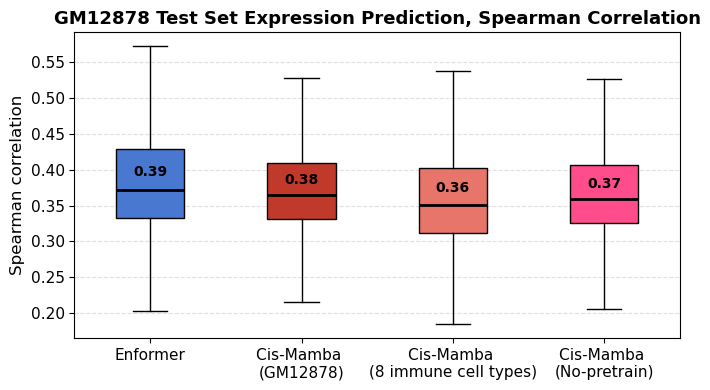

In [2]:
ordered_keys = [
    'enformer',
    'GM12878_no_mlm_predictions.npy',
    'immune_CAGE_predictions.npy',
    'nopretrain_predictions.npy',
]

pretty_labels = [
    'Enformer',
    'Cis-Mamba \n(GM12878)',
    'Cis-Mamba \n(8 immune cell types)',
    'Cis-Mamba \n(No-pretrain)',
]

colors = [
    '#4878CF',  # Enformer          — blue (matching dsQTL scheme)
    '#C0392B',  # GM12878 no-mlm    — dark red
    '#E8756A',  # 8 immune types    — salmon red
    '#FF4D8B',  # No-pretrain       — deep maroon (notably different)
]

data = [spearman_results[k] for k in ordered_keys]

plt.figure(figsize=(7, 4))
box = plt.boxplot(data, labels=pretty_labels, showfliers=False, patch_artist=True,
                  boxprops=dict(edgecolor='black'),
                  medianprops=dict(color='black', linewidth=2),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'))

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

for i, vals in enumerate(data):
    mean_val = np.mean(vals)
    plt.text(i + 1, mean_val, f"{mean_val:.2f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel("Spearman correlation", fontsize=12)
plt.title("GM12878 Test Set Expression Prediction, Spearman Correlation", fontsize=13, weight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# eQTL

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt

def predict_snp_effect_scores(ref_prob_preds, alt_prob_preds):
    """
    ref_prob_preds, alt_prob_preds: arrays of shape (N, L)
    returns five length-N arrays, with zeros for any row where both inputs are all-zero.
    """
    # 1) mask out rows where both ref & alt are entirely zero
    zero_mask = (ref_prob_preds.sum(axis=1) == 0) & (alt_prob_preds.sum(axis=1) == 0)
    valid    = ~zero_mask
    N        = ref_prob_preds.shape[0]
    
    # 2) prepare empty outputs
    logfc                    = np.zeros(N, dtype=float)
    log_probs_diff_abs_sum   = np.zeros(N, dtype=float)
    probs_jsd_diff           = np.zeros(N, dtype=float)
    integrative_effect_size  = np.zeros(N, dtype=float)
    integrative_effect_size2 = np.zeros(N, dtype=float)
    
    # 3) only compute on the valid rows
    if np.any(valid):
        r = ref_prob_preds[valid]
        a = alt_prob_preds[valid]
        
        # sum of absolute log-diffs
        lpd = np.sum(np.abs(np.log(a) - np.log(r)), axis=1)
        # Jensen-Shannon distance, one-by-one
        jsd = np.array([jensenshannon(x, y) for x,y in zip(a, r)])
        # log₂ fold-change of mean probabilities
        lf  = np.log2(r.mean(axis=1) / a.mean(axis=1))
        # two “integrative” sizes
        ies  = lf * jsd
        ies2 = lpd * jsd
        
        # 4) scatter them back into the full-size arrays
        log_probs_diff_abs_sum[valid]   = lpd
        probs_jsd_diff[valid]           = jsd
        logfc[valid]                    = lf
        integrative_effect_size[valid]  = ies
        integrative_effect_size2[valid] = ies2
    
    # 5) return—all-zero rows remain at zero
    return logfc, \
           log_probs_diff_abs_sum, \
           probs_jsd_diff, \
           integrative_effect_size, \
           integrative_effect_size2
           
def plot_metrics(out, labels, title):
    model_names = ['logfc', 'log_probs_diff_abs_sum', 'JSD', 'IED1', 'IED2']
    colors = ['blue', 'green', 'red', 'orange', 'purple']

    plt.figure(figsize=(6, 5))


    for i in range(len(model_names)):
        precision, recall, _ = precision_recall_curve(labels, np.abs(out[i]))
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'{model_names[i]} (AUC = {pr_auc:.3f})', color=colors[i])

    plt.title(title)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()

    plt.tight_layout()
    # plt.suptitle(title)
    plt.show()


qtls = pd.read_csv('/data1/lesliec/sarthak/data/joint_playground/eQTL/EPCOTv2_LCLs/LCLs.txt', sep=' ', header=None)
qtls.columns = ['label', 'qtl_idx', 'gene_idx', 'chrom', 'gene_start', 'gene_end', 'strand', 'qtl_loc', 'ref', 'alt', 'sign_target']
labels = qtls['label'].to_numpy()

def plot_selected_metric(files, labels, metric_name='logfc', sort_legend_by_auc=False, center=False, title='', mask=None):
    metric_index_map = {
        'logfc': 0,
        'log_probs_diff_abs_sum': 1,
        'JSD': 2,
        'IED1': 3,
        'IED2': 4
    }
    assert metric_name in metric_index_map, f"Invalid metric: {metric_name}"
    metric_idx = metric_index_map[metric_name]

    colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

    plt.figure(figsize=(6, 5))
    legend_entries = []

    for i, file in enumerate(files):
        eqtl_data = np.load(f'/data1/lesliec/sarthak/data/joint_playground/eQTL/EPCOTv2_LCLs/{file}')
        if center:
            center_start = eqtl_data.shape[1] // 2 - center[i] // 2
            center_end = center_start + center[i]
            eqtl_data = eqtl_data[:, center_start:center_end, :]
        out = predict_snp_effect_scores(eqtl_data[:, :, 0], eqtl_data[:, :, 1])

        if mask is None: #can supply a mask or can use default mask of the first value!
            if i == 0:
                non_zero_mask = (out[0] != 0)
        else:
            non_zero_mask = mask

        selected_metric = np.abs(out[metric_idx])[non_zero_mask]
        precision, recall, _ = precision_recall_curve(labels[non_zero_mask], selected_metric)
        pr_auc = auc(recall, precision)

        line, = plt.plot(recall, precision, label=file, color=colors[i % len(colors)])
        legend_entries.append((pr_auc, line, f'{file} (AUC = {pr_auc:.3f})'))

    plt.title(f'Precision-Recall Curve for {metric_name} {title}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')

    if sort_legend_by_auc:
        legend_entries.sort(reverse=True, key=lambda x: x[0])  # sort by AUC descending
    handles = [entry[1] for entry in legend_entries]
    labels_sorted = [entry[2] for entry in legend_entries]

    plt.legend(handles, labels_sorted)
    plt.tight_layout()
    plt.show()
    
import pickle
base_dir = '/data1/lesliec/sarthak/data/joint_playground/eQTL/EPCOTv2_LCLs/'
with open(base_dir+'genes.pickle', 'rb') as f:
    gene_annotation = pickle.load(f)

ordered_genes = sorted(list(gene_annotation.keys()))

tmpgeneTSS = np.loadtxt(base_dir+'ensemblTSS.txt', dtype='str')
geneTSS_dic = {tmpgeneTSS[i, 0]: int(tmpgeneTSS[i, 1]) for i in range(tmpgeneTSS.shape[0])}

distances = np.zeros((qtls.shape[0],), dtype=int)

for i in range(qtls.shape[0]):
    #initialize values and load in data
    temp = qtls.iloc[i]
    chrom   = 'chrX' if temp['chrom']==23 else 'chr'+str(temp['chrom'])
    pos     = temp['qtl_loc'] - 1  # Convert to zero-based index
    gene_idx= temp['gene_idx']
    tss_loc = geneTSS_dic[ordered_genes[gene_idx]]
    # print(tss_loc, pos)
    distances[i] = abs(tss_loc - pos)

import zarr
thresholds       = [1_000, 10_000, 524_288//2]
center = 16*128

auprc_by_threshold = []
for thr in thresholds:
    if thr == 1_000:
        mask = distances < thr
    elif thr == 10_000:
        mask = (distances >= 1_000) & (distances < thr)
    else:
        mask = (distances >= 10_000) & (distances < thr)
    
    row = []
    data = zarr.open('/data1/lesliec/sarthak/data/joint_playground/eQTL/EPCOTv2_LCLs/alphagenome_eqtl.zarr', mode='r')
    cs = data.shape[1] // 2 - center // 2
    ce = cs + center
    eqtl = data[:, cs:ce, :]
    out  = predict_snp_effect_scores(eqtl[:, :, 0], eqtl[:, :, 1])
    scores = np.abs(out[0])[mask]  # logFC metric
    pr, rc, _ = precision_recall_curve(labels[mask], scores)
    print(auc(rc, pr))

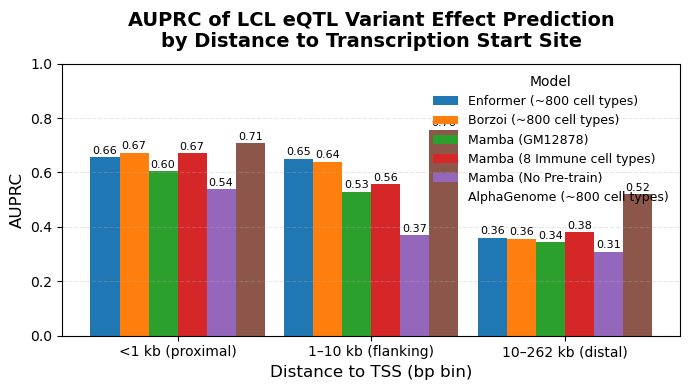

In [10]:
#lmfao it's so much better?!?????


files = ['enformer_eqtl.npy', 'borzoi_eqtl.npy', 'nomlm_maskonly.npy', 'immune.npy', 'nopretrain.npy', 'alphagenome_eqtl.zarr']

center = [16, 16*4, 16, 16, 16, 16*128]
threshold_names  = ['<1 kb (proximal)', '1–10 kb (flanking)', '10–262 kb (distal)']
model_files      = files
model_labels     = ['Enformer (~800 cell types)', 'Borzoi (~800 cell types)', 'Mamba (GM12878)',
                    'Mamba (8 Immune cell types)', 'Mamba (No Pre-train)', 'AlphaGenome (~800 cell types)']


auprc_by_threshold = []
for thr in thresholds:
    if thr == 1_000:
        mask = distances < thr
    elif thr == 10_000:
        mask = (distances >= 1_000) & (distances < thr)
    else:
        mask = (distances >= 10_000) & (distances < thr)

    row = []
    for i, fname in enumerate(model_files):
        if 'zarr' in fname:
            data = zarr.open(f'/data1/lesliec/sarthak/data/joint_playground/eQTL/EPCOTv2_LCLs/{fname}', mode='r')
        else:
            data = np.load(f'/data1/lesliec/sarthak/data/joint_playground/eQTL/EPCOTv2_LCLs/{fname}')
        cs = data.shape[1] // 2 - center[i] // 2
        ce = cs + center[i]
        eqtl = data[:, cs:ce, :]
        out  = predict_snp_effect_scores(eqtl[:, :, 0], eqtl[:, :, 1])
        scores = np.abs(out[0])[mask]  # logFC metric
        pr, rc, _ = precision_recall_curve(labels[mask], scores)
        row.append(auc(rc, pr))
    auprc_by_threshold.append(row)
auprc = np.array(auprc_by_threshold)  # shape (3,5)

# --- plotting ---
x         = np.arange(len(thresholds))
bar_width = 0.15

plt.figure(figsize=(7, 4))
for i, label in enumerate(model_labels):
    plt.bar(x + i*bar_width,
            auprc[:, i],
            width=bar_width,
            label=label)

# Annotate bar heights
for i in range(len(thresholds)):
    for j in range(len(model_labels)):
        y = auprc[i, j]
        plt.text(x[i] + j*bar_width, y + 0.005,
                 f'{y:.2f}', ha='center', va='bottom', fontsize=8)

# Styling
plt.xticks(x + (len(model_labels)-1)/2*bar_width, threshold_names, fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.xlabel('Distance to TSS (bp bin)', fontsize=12)
plt.ylabel('AUPRC', fontsize=12)
plt.title('AUPRC of LCL eQTL Variant Effect Prediction\nby Distance to Transcription Start Site', 
          fontsize=14, fontweight='bold', pad=12)

# leg = plt.legend(title='Model', fontsize=9, title_fontsize=10,
#                  bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
leg = plt.legend(title='Model', fontsize=9, title_fontsize=10, loc='upper right', frameon=False)

plt.tight_layout()
plt.show()

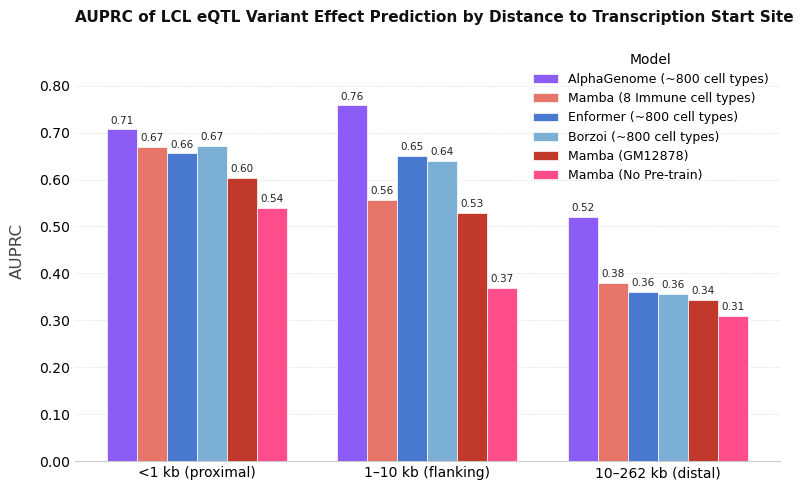

In [13]:
colors = [
    '#4878CF',  # Enformer          — blue
    '#7BAFD4',  # Borzoi            — light blue
    '#C0392B',  # Mamba GM12878     — dark red
    '#E8756A',  # Mamba 8 immune    — salmon red
    "#FF4D8B",  # Mamba no-pretrain — pink-red
    '#8B5CF6',  # AlphaGenome       — purple
]

# Sort model order by descending AUPRC in the last (distal) threshold
distal_auprcs = auprc[2, :]  # last row = distal
sort_order = np.argsort(distal_auprcs)[::-1]

sorted_labels = [model_labels[i] for i in sort_order]
sorted_colors = [colors[i] for i in sort_order]
sorted_auprc  = auprc[:, sort_order]  # shape (3, n_models)

x = np.arange(len(thresholds))
n_models  = len(sorted_labels)
bar_width = 0.13
total_width = bar_width * n_models
offsets = np.linspace(-total_width/2, total_width/2, n_models, endpoint=False) + bar_width/2

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for i, (label, color) in enumerate(zip(sorted_labels, sorted_colors)):
    bars = ax.bar(x + offsets[i], sorted_auprc[:, i],
                  width=bar_width, label=label,
                  color=color, edgecolor='white', linewidth=0.5, zorder=3)
    for bar, val in zip(bars, sorted_auprc[:, i]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=7.5, color='#222222')

ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='#DDDDDD', zorder=0)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(threshold_names, fontsize=11)
ax.set_ylabel('AUPRC', fontsize=12, color='#444444', labelpad=10)
ax.set_ylim(0, sorted_auprc.max() * 1.18)
ax.tick_params(axis='both', length=0, labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['bottom'].set_linewidth(0.8)

ax.set_title(
    'AUPRC of LCL eQTL Variant Effect Prediction by Distance to Transcription Start Site',
    fontsize=11, fontweight='bold', color='#111111', pad=14, loc='left'
)
ax.legend(title='Model', fontsize=9, title_fontsize=10,
          loc='upper right', frameon=False)

plt.tight_layout()
plt.show()

# e2g results

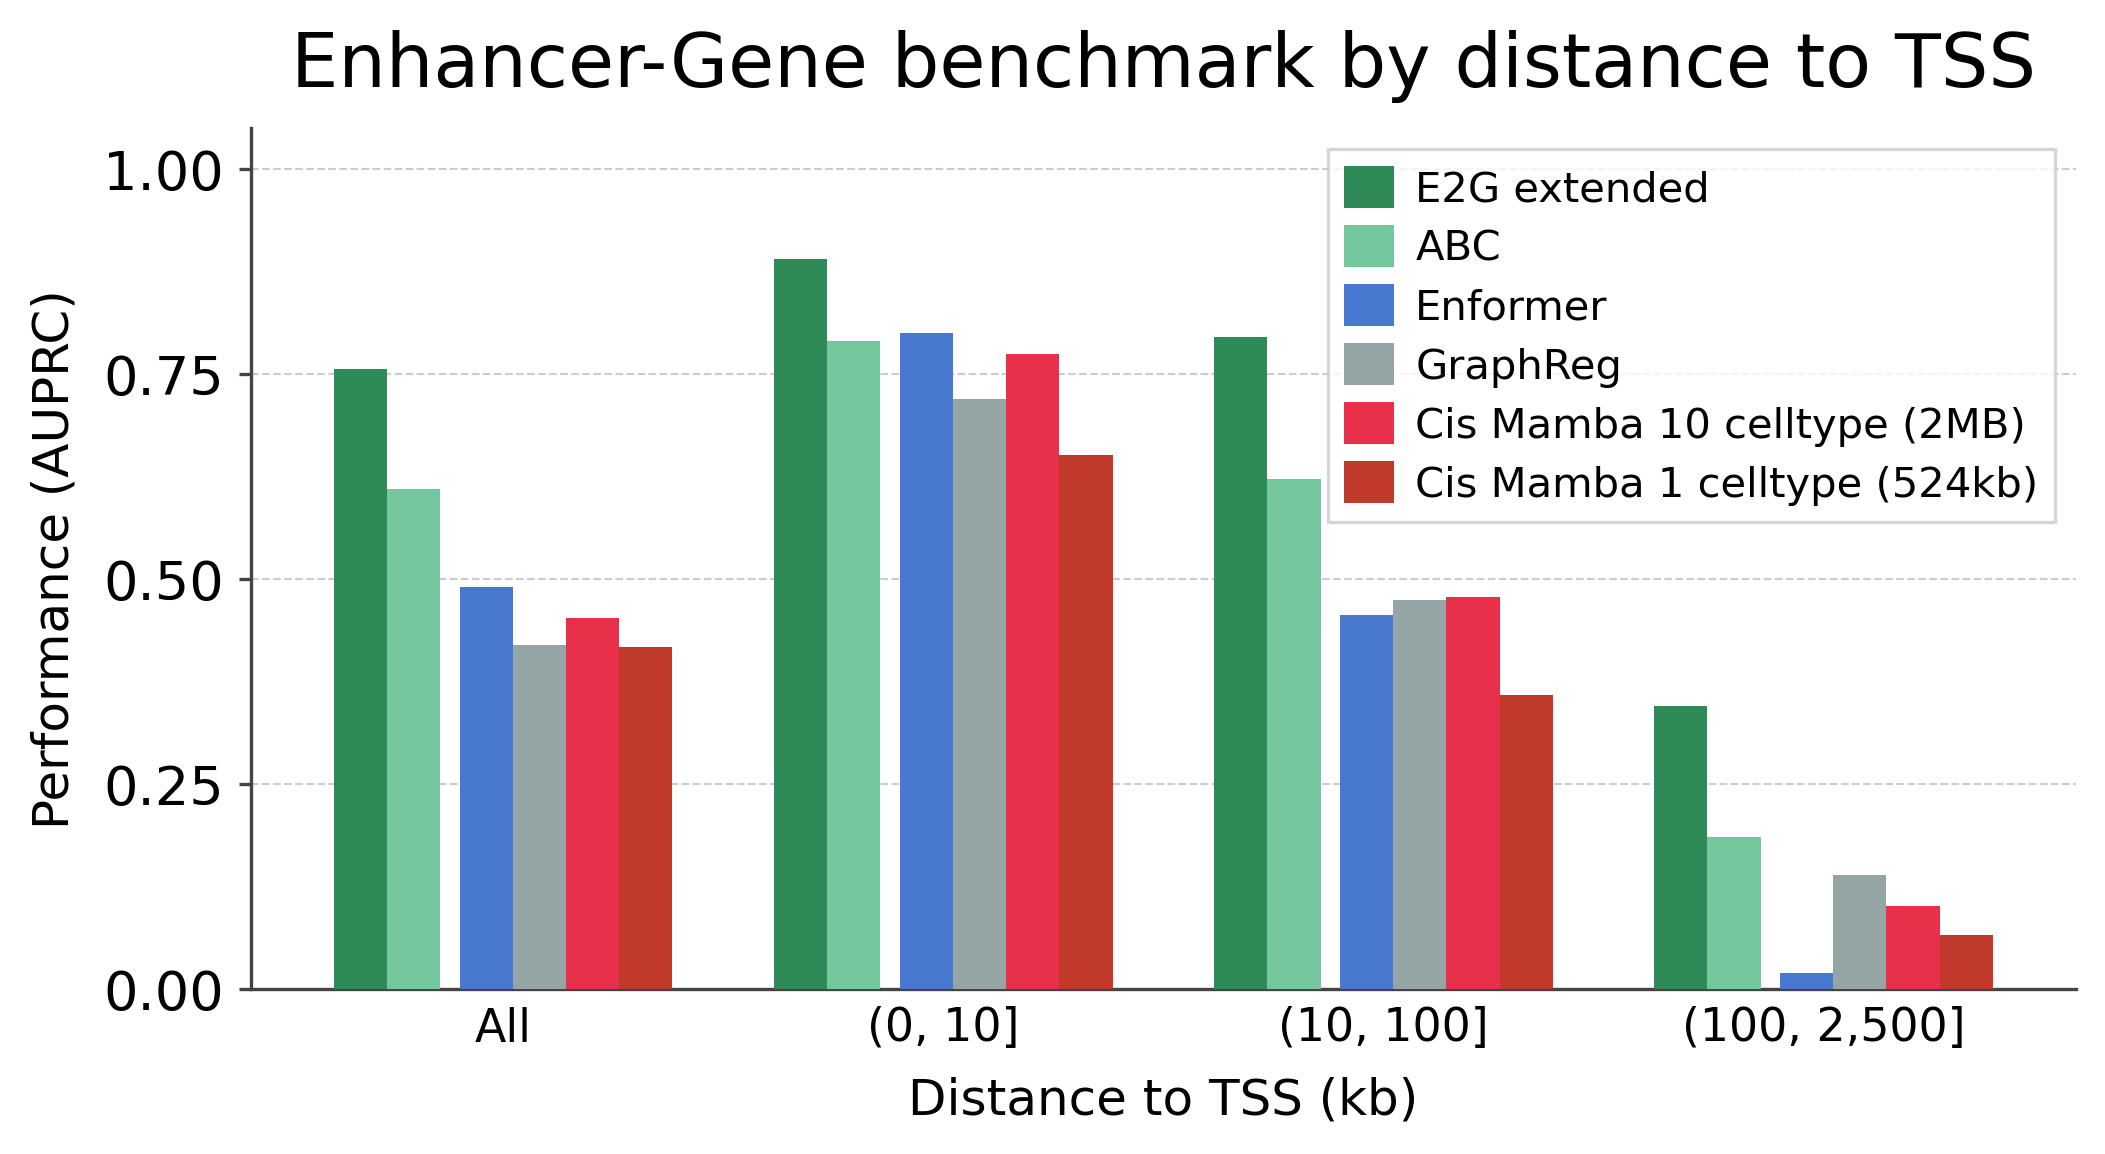

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

values_dict = {
    "E2G extended": [0.756, 0.89, 0.795, 0.346],
    # "E2G":          [0.635, 0.818, 0.627, 0.175],
    "ABC":          [0.610, 0.790, 0.622, 0.186],
    "Enformer":     [0.490, 0.800, 0.456, 0.020],
    "GraphReg":     [0.420, 0.720, 0.475, 0.139],
    "Cis Mamba 10 celltype (2MB)":    [0.453, 0.775, 0.478, 0.101],
    "Cis Mamba 1 celltype (524kb)":    [0.417, 0.651, 0.359, 0.066],
}

categories = ["All", "(0, 10]", "(10, 100]", "(100, 2,500]"]
methods = list(values_dict.keys())
# colors = ["#6B1A35", "#7B5EA7", "#4A9B8E", "#9B6DB5", "#C4A8DC", "#6BAED6"]
colors = [
    '#2E8B57',  # E2G extended          — dark green (strong external baseline)
    '#74C69D',  # ABC                   — light green (external baseline)
    '#4878CF',  # Enformer              — blue
    '#95A5A6',  # GraphReg              — muted gray (separate method family)
    '#E8304A',  # Cis-Mamba 10 celltype — dark red
    '#C0392B',  # Cis-Mamba 1 celltype  — salmon red
]

n_categories = len(categories)
n_methods = len(methods)
bar_width = 0.11
group_spacing = 0.25
x = np.arange(n_categories) * (n_methods * bar_width + group_spacing)

mpl.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 10,
    "figure.dpi": 300,
})

fig, ax = plt.subplots(figsize=(7, 3.5))

gap = 0.04  # spacing between first 2 and the rest

for i, (method, color) in enumerate(zip(methods, colors)):
    extra = gap if i >= 2 else 0
    offsets = x + i * bar_width + extra
    ax.bar(offsets, values_dict[method], width=bar_width, label=method,
           color=color, linewidth=0, zorder=3)

# account for the gap when centering x tick labels
group_centers = x + (n_methods - 1) * bar_width / 2 + gap / 2
ax.set_xticks(group_centers)
ax.set_xticklabels(categories, fontsize=11)
ax.set_xlabel("Distance to TSS (kb)", labelpad=6, fontsize=12)
ax.set_ylabel("Performance (AUPRC)", labelpad=6, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])

ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#CCCCCC", zorder=0)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")
ax.tick_params(axis="x", length=0, pad=4)
ax.tick_params(axis="y", length=3, width=0.8, color="#444444")

leg = ax.legend(
    frameon=True,
    # fontsize=11,
    ncol=1,
    loc="upper right",
    handlelength=1.2,
    handleheight=1.2,
    handletextpad=0.5,
    labelspacing=0.35,
    bbox_to_anchor=(1.0, 1.0),
    edgecolor="#CCCCCC",
    fancybox=False,
)
leg.get_frame().set_linewidth(0.8)


plt.tight_layout(pad=0.5)
plt.title("Enhancer-Gene benchmark by distance to TSS", fontsize=18, pad=10)
# plt.savefig("crispr_performance.pdf", bbox_inches="tight")
# plt.savefig("crispr_performance.png", dpi=300, bbox_inches="tight")
plt.show()